# 03_ModelComparison

동일한 데이터·피처 파이프라인 위에서 Random Forest / XGBoost / RNN 비교.

| 모델 | 입력 형식 | 특징 |
|---|---|---|
| Random Forest | (N, 30) 윈도우 통계 피처 | 소규모 데이터 강인, 해석 용이 |
| XGBoost | (N, 30) 윈도우 통계 피처 | 부스팅, 클래스 불균형 대응 |
| RNN | (N, 30, 5) 시계열 원본 | LSTM과 비교용, 게이트 없는 순환망 |

In [37]:
# 필수 패키지 설치 (최초 1회)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost', 'scipy'])

0

In [38]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'comparison_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

# RNN 하이퍼파라미터
RNN_HIDDEN_1        = 64
RNN_HIDDEN_2        = 32
DROPOUT_RATE        = 0.3
EPOCHS              = 200
BATCH_SIZE          = 32
LEARNING_RATE       = 1e-3
EARLY_STOP_PATIENCE = 20
RANDOM_SEED         = 42

print(f'WINDOW_SIZE: {WINDOW_SIZE}, STEP_SIZE: {STEP_SIZE}')

WINDOW_SIZE: 30, STEP_SIZE: 10


In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import linregress

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| Device:', DEVICE)
print('XGBoost:', xgb.__version__)

PyTorch: 2.11.0+cu128 | Device: cuda
XGBoost: 3.2.0


In [40]:
# =========================
# 데이터 로드 (Avg Voltage, Avg Current만 사용)
# Trial 내 z-score로 DC 레벨 제거
# =========================

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError(f'라벨 없음: {prefix}{idx}')

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

def load_all_trials(base_dir):
    records = []
    for d in sorted(base_dir.iterdir()):
        if not d.is_dir(): continue
        prefix, idx = parse_folder_id(d.name)
        if prefix is None: continue
        try:
            label = get_label(prefix, idx)
            split = get_split(prefix, idx)
        except ValueError: continue
        csvs = list(d.glob('*.csv'))
        if not csvs: continue
        data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
        mean, std = data.mean(0), data.std(0)
        std[std < 1e-8] = 1e-8
        data_norm = (data - mean) / std   # (n, 2) — V, I만
        records.append({'folder': d.name, 'label': label, 'split': split,
                        'data': data_norm})
    return records

records = load_all_trials(BASE_DIR)
print(f'총 {len(records)}개 trial 로드 완료')

# 슬라이딩 윈도우
def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}

# 글로벌 스케일러 (RNN 입력용)
n_feat  = X['train'].shape[2]   # 2
scaler  = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):4d}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

총 19개 trial 로드 완료
train  total= 364  normal= 183  abnormal= 181
val    total=  58  normal=  29  abnormal=  29
test   total= 150  normal=  95  abnormal=  55


In [41]:
# =========================
# 윈도우 → 통계 피처 변환 (RF / XGBoost 입력)
# 각 윈도우(30×2)에서 피처별 6종 통계 추출 → 12차원
# =========================

FEAT_NAMES = ['V', 'I']
STAT_NAMES = ['mean', 'std', 'min', 'max', 'range', 'slope']

def window_stats(windows):   # (N, 30, 2) → (N, 12)
    N = len(windows)
    t = np.arange(WINDOW_SIZE)
    out = np.zeros((N, len(FEAT_NAMES) * len(STAT_NAMES)), dtype=np.float32)
    for i, w in enumerate(windows):
        row = []
        for f in range(len(FEAT_NAMES)):
            col = w[:, f]
            slope = linregress(t, col).slope
            row.extend([col.mean(), col.std(), col.min(), col.max(),
                        col.max() - col.min(), slope])
        out[i] = row
    return out

print('윈도우 통계 피처 계산 중...')
Xf = {s: window_stats(Xs[s]) for s in Xs}

flat_scaler = StandardScaler()
flat_scaler.fit(Xf['train'])
Xf = {s: flat_scaler.transform(Xf[s]).astype(np.float32) for s in Xf}

Xf_tv = np.vstack([Xf['train'], Xf['val']])
yf_tv  = np.concatenate([y['train'], y['val']]).astype(int)

col_names = [f'{f}_{s}' for f in FEAT_NAMES for s in STAT_NAMES]
print(f'통계 피처 shape: {Xf["train"].shape}  컬럼: {col_names}')

윈도우 통계 피처 계산 중...
통계 피처 shape: (364, 12)  컬럼: ['V_mean', 'V_std', 'V_min', 'V_max', 'V_range', 'V_slope', 'I_mean', 'I_std', 'I_min', 'I_max', 'I_range', 'I_slope']


In [42]:
# =========================
# 공통 평가 함수 (윈도우 단위, threshold=0.5 고정)
# =========================

roc_data = {}   # 최종 비교용
results  = {}

def evaluate(model_name, y_true, y_prob):
    y_pred  = (y_prob >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    prec    = precision_score(y_true, y_pred, zero_division=0)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    f1      = f1_score(y_true, y_pred, zero_division=0)

    print(f'\n===== {model_name} (threshold=0.5) =====')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

    roc_data[model_name] = (y_true, y_prob)
    results[model_name]  = {'precision': prec, 'recall': rec, 'f1': f1,
                             'roc_auc': roc_auc, 'pr_auc': pr_auc}
    return roc_auc, pr_auc


def plot_curves(roc_data, title_prefix=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))

    for (name, (yt, yp)), c in zip(roc_data.items(), colors):
        fpr, tpr, _ = roc_curve(yt, yp)
        axes[0].plot(fpr, tpr, lw=2, color=c,
                     label=f'{name} ({roc_auc_score(yt, yp):.3f})')
        pre, rec, _ = precision_recall_curve(yt, yp)
        axes[1].plot(rec, pre, lw=2, color=c,
                     label=f'{name} ({average_precision_score(yt, yp):.3f})')

    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'{title_prefix}ROC Curve'); axes[0].legend()

    baseline = list(roc_data.values())[0][0].mean()
    axes[1].axhline(baseline, color='k', linestyle='--', lw=1,
                    label=f'Baseline={baseline:.2f}')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix}PR Curve'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(str(MODEL_DIR / 'roc_pr_comparison.png'), dpi=150)
    plt.show()

print('평가 함수 준비 완료')

평가 함수 준비 완료



===== Random Forest (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.68      0.93      0.78        95
 Abnormal(1)       0.65      0.24      0.35        55

    accuracy                           0.67       150
   macro avg       0.66      0.58      0.56       150
weighted avg       0.67      0.67      0.62       150

ROC-AUC : 0.5567  |  PR-AUC : 0.4547


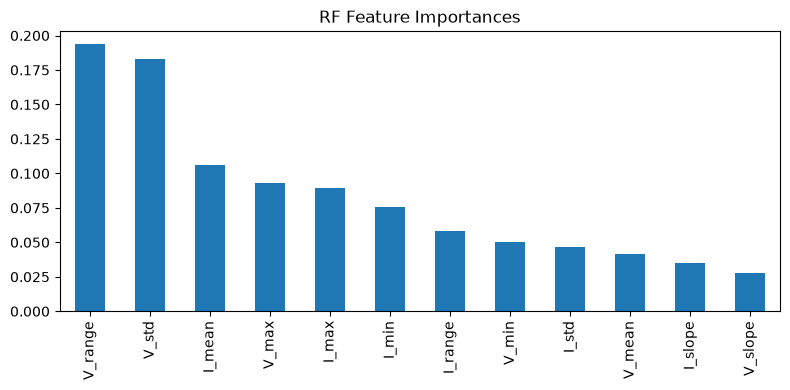

In [43]:
# =========================
# Random Forest
# =========================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(Xf_tv, yf_tv)

rf_prob = rf.predict_proba(Xf['test'])[:, 1]
evaluate('Random Forest', y['test'].astype(int), rf_prob)

# 피처 중요도
importances = pd.Series(rf.feature_importances_, index=col_names).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar')
plt.title('RF Feature Importances')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'rf_feature_importance.png'), dpi=150)
plt.show()

Best iteration: 17  (500 중 18번째에서 early stop)

===== XGBoost (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.67      0.91      0.77        95
 Abnormal(1)       0.57      0.22      0.32        55

    accuracy                           0.65       150
   macro avg       0.62      0.56      0.54       150
weighted avg       0.63      0.65      0.60       150

ROC-AUC : 0.6439  |  PR-AUC : 0.4976


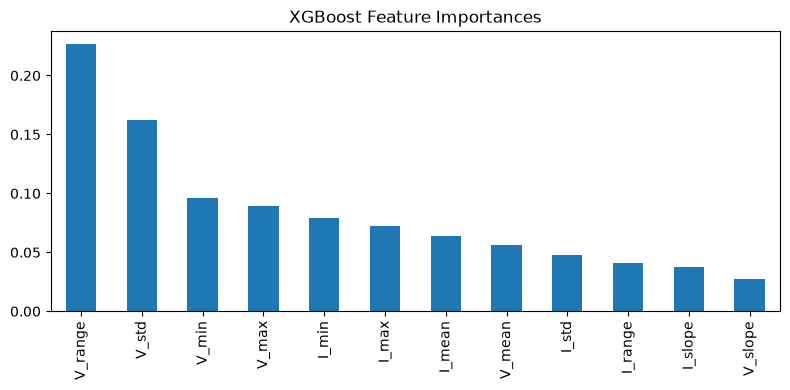

In [44]:
# =========================
# XGBoost (early_stopping_rounds=20)
# =========================

scale_pos = int((yf_tv == 0).sum()) / int((yf_tv == 1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=RANDOM_SEED,
    verbosity=0
)
xgb_model.fit(
    Xf['train'], y['train'].astype(int),
    eval_set=[(Xf['val'], y['val'].astype(int))],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}  (500 중 {xgb_model.best_iteration+1}번째에서 early stop)')

xgb_prob = xgb_model.predict_proba(Xf['test'])[:, 1]
evaluate('XGBoost', y['test'].astype(int), xgb_prob)

# 피처 중요도
xgb_imp = pd.Series(xgb_model.feature_importances_, index=col_names).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
xgb_imp.plot(kind='bar')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'xgb_feature_importance.png'), dpi=150)
plt.show()

In [45]:
# =========================
# RNN 모델 정의
# =========================

class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1 = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2 = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x)
        out = self.drop1(out)
        out, _ = self.rnn2(out)
        out = self.drop2(out[:, -1, :])
        return torch.sigmoid(self.fc(out)).squeeze(-1)


class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


rnn_model = RNNAnomalyDetector(n_feat, RNN_HIDDEN_1, RNN_HIDDEN_2, DROPOUT_RATE).to(DEVICE)
rnn_crit  = nn.BCELoss()
rnn_optim = torch.optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)

train_loader = DataLoader(WindowDataset(Xs['train'], y['train']), BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WindowDataset(Xs['val'],   y['val']),   BATCH_SIZE)
test_loader  = DataLoader(WindowDataset(Xs['test'],  y['test']),  BATCH_SIZE)

print(rnn_model)
total = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f'\nTrainable params: {total:,}')

RNNAnomalyDetector(
  (rnn1): RNN(2, 64, batch_first=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (rnn2): RNN(64, 32, batch_first=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Trainable params: 7,521


Epoch   1  train_loss=0.6993  train_acc=0.4533  val_loss=0.6942  val_acc=0.5000
Epoch  10  train_loss=0.6877  train_acc=0.5165  val_loss=0.6963  val_acc=0.4828
Epoch  20  train_loss=0.5800  train_acc=0.7335  val_loss=0.8099  val_acc=0.3966
Epoch  30  train_loss=0.4152  train_acc=0.8242  val_loss=0.8573  val_acc=0.4655
Epoch  40  train_loss=0.5345  train_acc=0.7473  val_loss=0.7489  val_acc=0.6379
Epoch  50  train_loss=0.3446  train_acc=0.8599  val_loss=0.8481  val_acc=0.6034

Early stopping at epoch 51

학습 완료  best_val_loss=0.6692


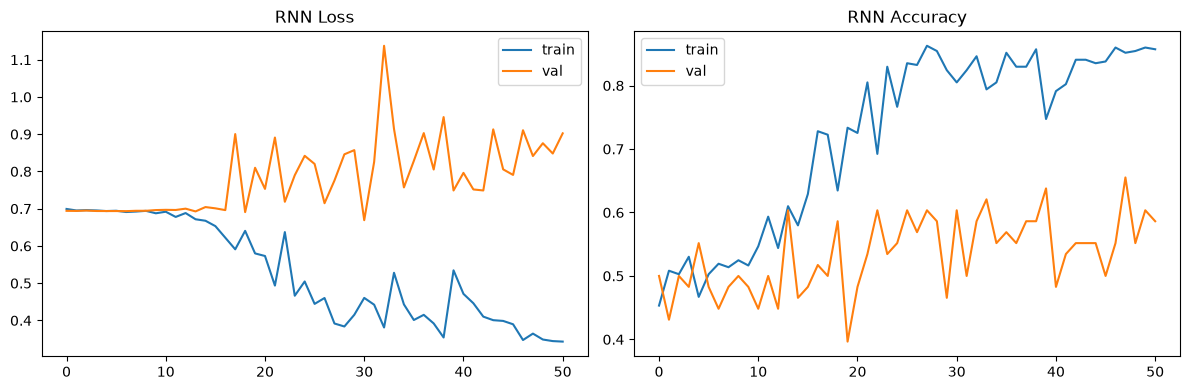

In [46]:
# =========================
# RNN 학습 (EarlyStopping patience=20)
# =========================

best_val_loss    = float('inf')
patience_counter = 0
rnn_path         = str(MODEL_DIR / 'best_rnn.pt')
rnn_history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


def run_epoch(model, loader, optim=None):
    train = optim is not None
    model.train() if train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            if train: optim.zero_grad()
            pred = model(Xb)
            loss = rnn_crit(pred, yb)
            if train: loss.backward(); optim.step()
            total_loss    += loss.item() * len(yb)
            total_correct += ((pred >= 0.5).float() == yb).sum().item()
            total_n       += len(yb)
    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(rnn_model, train_loader, rnn_optim)
    vl_loss, vl_acc = run_epoch(rnn_model, val_loader)
    rnn_history['train_loss'].append(tr_loss)
    rnn_history['val_loss'].append(vl_loss)
    rnn_history['train_acc'].append(tr_acc)
    rnn_history['val_acc'].append(vl_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}  '
              f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
              f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_counter = 0
        torch.save(rnn_model.state_dict(), rnn_path)
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

rnn_model.load_state_dict(torch.load(rnn_path, map_location=DEVICE))
print(f'\n학습 완료  best_val_loss={best_val_loss:.4f}')

# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rnn_history['train_loss'], label='train')
axes[0].plot(rnn_history['val_loss'],   label='val')
axes[0].set_title('RNN Loss'); axes[0].legend()
axes[1].plot(rnn_history['train_acc'], label='train')
axes[1].plot(rnn_history['val_acc'],   label='val')
axes[1].set_title('RNN Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'rnn_training_curve.png'), dpi=150)
plt.show()

In [47]:
# =========================
# RNN 평가 (윈도우 단위, threshold=0.5)
# =========================

rnn_model.eval()
all_prob, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        all_prob.append(rnn_model(Xb.to(DEVICE)).cpu().numpy())
        all_true.append(yb.numpy())

rnn_prob = np.concatenate(all_prob)
rnn_true = np.concatenate(all_true).astype(int)

evaluate('RNN', rnn_true, rnn_prob)


===== RNN (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.65      0.98      0.78        95
 Abnormal(1)       0.71      0.09      0.16        55

    accuracy                           0.65       150
   macro avg       0.68      0.53      0.47       150
weighted avg       0.67      0.65      0.55       150

ROC-AUC : 0.5782  |  PR-AUC : 0.4791


(0.5781818181818181, 0.4791263580997033)

=== Window-level 비교 (threshold=0.5) ===
        Model  Precision  Recall    F1  ROC-AUC  PR-AUC
Random Forest      0.650   0.236 0.347    0.557   0.455
      XGBoost      0.571   0.218 0.316    0.644   0.498
          RNN      0.714   0.091 0.161    0.578   0.479


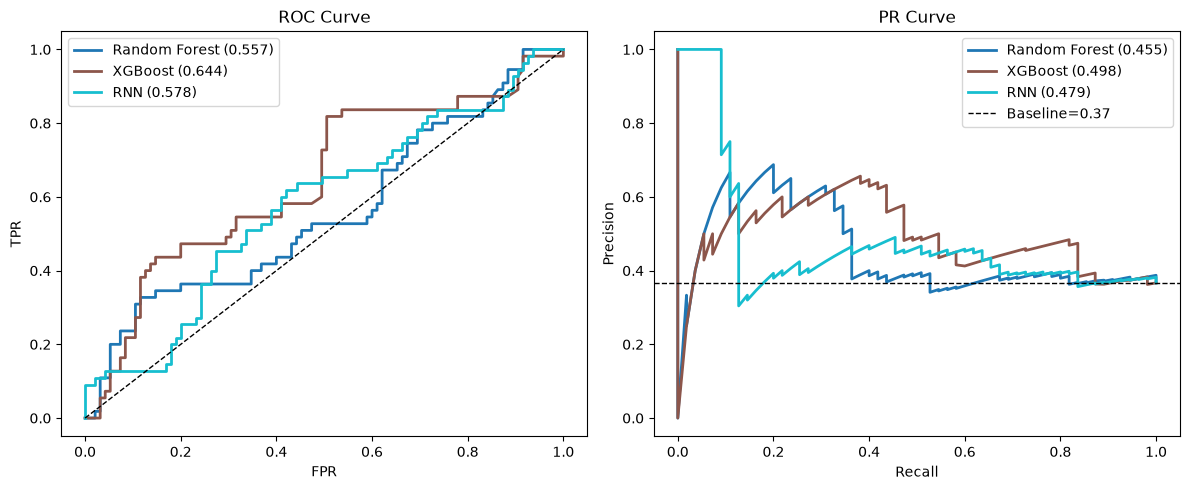

In [48]:
# =========================
# 모델 비교 요약 (윈도우 단위)
# =========================

df = pd.DataFrame([
    {
        'Model':     name,
        'Precision': round(v['precision'], 3),
        'Recall':    round(v['recall'],    3),
        'F1':        round(v['f1'],        3),
        'ROC-AUC':   round(v['roc_auc'],   3),
        'PR-AUC':    round(v['pr_auc'],    3),
    }
    for name, v in results.items()
])
print('=== Window-level 비교 (threshold=0.5) ===')
print(df.to_string(index=False))

# ROC + PR 곡선
plot_curves(roc_data)